# Phase 10 - Modeling Sentiment LPDPNotebook ini menjalankan tiga tier modeling:- Tier 1: Naive Bayes, Logistic Regression, Linear SVC- Tier 2: IndoBERT fine-tuning 5 epoch- Tier 3 opsional: retrieval/RAG-style data augmentation jika F1 kelas minority < 0.60Asumsi utama:- TF-IDF/BoW memakai `data/processed/dataset_lpdp_preprocessed.csv` kolom `text_clean`- IndoBERT memakai `data/processed/dataset_lpdp_preprocessed_bert.csv` kolom `text_bert`- Target label memakai kolom `Sentiment`


## 1. Setup Library dan Konfigurasi

In [4]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "uninstall",
    "-y", "torch", "torchvision", "torchaudio"
])

0

In [5]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "torch==2.4.1",
    "torchvision==0.19.1",
    "torchaudio==2.4.1",
    "--index-url", "https://download.pytorch.org/whl/cpu"
])

0

In [6]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.4.1+cpu
CUDA available: False


In [7]:
import os
import random
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

c:\Users\Salwa\AppData\Local\Programs\Python\Python38\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 2. Load Data Train dan Test

Cell ini mendukung dua skenario:

1. Jika sudah ada `train.csv` dan `test.csv`, file itu akan dipakai.
2. Jika belum ada, notebook membuat split otomatis dari dataset preprocessing, lalu menyimpan `train_modeling.csv` dan `test_modeling.csv`.


In [8]:
from pathlib import Path

In [9]:
PROJECT_DIR = Path(".")SPLIT_DIR = PROJECT_DIR / "output_split"TRACK_A_TRAIN_PATH = SPLIT_DIR / "outputs/output_split/track_a_train.csv"TRACK_A_TEST_PATH = SPLIT_DIR / "outputs/output_split/track_a_test.csv"TRACK_B_TRAIN_PATH = SPLIT_DIR / "outputs/output_split/track_b_train.csv"TRACK_B_TEST_PATH = SPLIT_DIR / "outputs/output_split/track_b_test.csv"LABEL_COL = "Sentiment"LABEL_ENCODED_COL = "label_encoded"TEXT_CLEAN_COL = "text_clean"TEXT_BERT_COL = "text_bert"ID_COL = "doc_id"


In [10]:
def validate_file_exists(path):
    if not Path(path).exists():
        raise FileNotFoundError(f"File tidak ditemukan: {path}")


def load_track_split(track_a_path, track_b_path, split_name):
    """
    Load hasil split Phase 9:
    - Track A berisi text_clean untuk TF-IDF / BoW / Tier 1
    - Track B berisi text_bert untuk IndoBERT / Tier 2
    Keduanya digabung berdasarkan doc_id.
    """

    validate_file_exists(track_a_path)
    validate_file_exists(track_b_path)

    df_a = pd.read_csv(track_a_path)
    df_b = pd.read_csv(track_b_path)

    required_a = [ID_COL, TEXT_CLEAN_COL, LABEL_COL, LABEL_ENCODED_COL]
    required_b = [ID_COL, TEXT_BERT_COL, LABEL_COL, LABEL_ENCODED_COL]

    for col in required_a:
        if col not in df_a.columns:
            raise ValueError(f"Kolom {col} tidak ada di {track_a_path}")

    for col in required_b:
        if col not in df_b.columns:
            raise ValueError(f"Kolom {col} tidak ada di {track_b_path}")

    df_a = df_a[required_a].copy()
    df_b = df_b[required_b].copy()

    df_merged = df_a.merge(
        df_b[[ID_COL, TEXT_BERT_COL, LABEL_COL, LABEL_ENCODED_COL]],
        on=ID_COL,
        how="inner",
        suffixes=("_track_a", "_track_b"),
        validate="one_to_one"
    )

    if len(df_merged) != len(df_a) or len(df_merged) != len(df_b):
        raise ValueError(
            f"Jumlah baris {split_name} berubah setelah merge. "
            f"Track A={len(df_a)}, Track B={len(df_b)}, merged={len(df_merged)}"
        )

    same_label = df_merged[f"{LABEL_COL}_track_a"].astype(str).str.lower().equals(
        df_merged[f"{LABEL_COL}_track_b"].astype(str).str.lower()
    )

    same_encoded = df_merged[f"{LABEL_ENCODED_COL}_track_a"].equals(
        df_merged[f"{LABEL_ENCODED_COL}_track_b"]
    )

    if not same_label:
        raise ValueError(f"Label Sentiment Track A dan Track B tidak sama pada split {split_name}.")

    if not same_encoded:
        raise ValueError(f"label_encoded Track A dan Track B tidak sama pada split {split_name}.")

    df_merged = df_merged.rename(columns={
        f"{LABEL_COL}_track_a": LABEL_COL,
        f"{LABEL_ENCODED_COL}_track_a": LABEL_ENCODED_COL
    })

    df_merged = df_merged.drop(columns=[
        f"{LABEL_COL}_track_b",
        f"{LABEL_ENCODED_COL}_track_b"
    ])

    df_merged[TEXT_CLEAN_COL] = df_merged[TEXT_CLEAN_COL].fillna("").astype(str)
    df_merged[TEXT_BERT_COL] = df_merged[TEXT_BERT_COL].fillna("").astype(str)
    df_merged[LABEL_COL] = df_merged[LABEL_COL].astype(str).str.lower()
    df_merged[LABEL_ENCODED_COL] = df_merged[LABEL_ENCODED_COL].astype(int)

    empty_clean = df_merged[TEXT_CLEAN_COL].str.strip().eq("").sum()
    empty_bert = df_merged[TEXT_BERT_COL].str.strip().eq("").sum()

    if empty_clean > 0:
        raise ValueError(f"Ada {empty_clean} baris text_clean kosong pada split {split_name}.")

    if empty_bert > 0:
        raise ValueError(f"Ada {empty_bert} baris text_bert kosong pada split {split_name}.")

    return df_merged


train_df = load_track_split(
    TRACK_A_TRAIN_PATH,
    TRACK_B_TRAIN_PATH,
    "train"
)

test_df = load_track_split(
    TRACK_A_TEST_PATH,
    TRACK_B_TEST_PATH,
    "test"
)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nKolom train:")
print(train_df.columns.tolist())

print("\nDistribusi label train:")
print(train_df[LABEL_COL].value_counts().sort_index())

print("\nDistribusi label test:")
print(test_df[LABEL_COL].value_counts().sort_index())

print("\nCek label_encoded train:")
print(
    train_df[[LABEL_COL, LABEL_ENCODED_COL]]
    .drop_duplicates()
    .sort_values(LABEL_ENCODED_COL)
    .to_string(index=False)
)

Train shape: (830, 5)
Test shape : (208, 5)

Kolom train:
['doc_id', 'text_clean', 'Sentiment', 'label_encoded', 'text_bert']

Distribusi label train:
Sentiment
negative    249
neutral     273
positive    308
Name: count, dtype: int64

Distribusi label test:
Sentiment
negative    62
neutral     69
positive    77
Name: count, dtype: int64

Cek label_encoded train:
Sentiment  label_encoded
 negative              0
  neutral              1
 positive              2


## 3. Label Encoding

In [11]:
# Label sudah dibuat pada Phase 9 Train/Test Split.
# Gunakan label_encoded dari output_split agar mapping label konsisten.

y_train = train_df[LABEL_ENCODED_COL].astype(int).to_numpy()
y_test = test_df[LABEL_ENCODED_COL].astype(int).to_numpy()

# Ambil mapping label dari train + test
label_mapping_df = pd.concat([
    train_df[[LABEL_COL, LABEL_ENCODED_COL]],
    test_df[[LABEL_COL, LABEL_ENCODED_COL]]
]).drop_duplicates().sort_values(LABEL_ENCODED_COL)

label_names = label_mapping_df[LABEL_COL].tolist()
num_labels = len(label_names)

# Buat LabelEncoder agar tetap kompatibel dengan kode lain
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(label_names)

# Mapping untuk IndoBERT
id2label = {
    int(row[LABEL_ENCODED_COL]): row[LABEL_COL]
    for _, row in label_mapping_df.iterrows()
}

label2id = {
    label: idx
    for idx, label in id2label.items()
}

print("Label mapping dari Phase 9:")
for idx in sorted(id2label):
    print(f"{idx}: {id2label[idx]}")

print("\ny_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nJumlah label:", num_labels)
print("Label names:", label_names)

Label mapping dari Phase 9:
0: negative
1: neutral
2: positive

y_train shape: (830,)
y_test shape : (208,)

Jumlah label: 3
Label names: ['negative', 'neutral', 'positive']


## 4. Tier 1 - Hyperparameter Tuning: Naive Bayes, Logistic Regression, Linear SVC

Tier 1 memakai `text_clean` dari dataset preprocessing TF-IDF/BoW.

Setiap model akan mencari kombinasi parameter terbaik dengan `GridSearchCV`, terutama variasi `ngram_range` umum: unigram `(1,1)`, unigram+bigram `(1,2)`, dan unigram+bigram+trigram `(1,3)`. Skor utama yang dipakai untuk memilih model terbaik adalah `macro_f1`, karena lebih adil untuk kelas yang tidak seimbang.


In [12]:
# Tier 1 Hyperparameter Tuning dengan GridSearchCV# TF-IDF/BoW baseline memakai data/processed/dataset_lpdp_preprocessed.csv kolom text_clean.X_train_tier1 = train_df[TEXT_CLEAN_COL]X_test_tier1 = test_df[TEXT_CLEAN_COL]cv_strategy = StratifiedKFold(    n_splits=5,    shuffle=True,    random_state=SEED)base_tfidf_params = {    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],    'tfidf__min_df': [1, 2],    'tfidf__max_df': [0.90, 0.95],    'tfidf__max_features': [5000, 10000],    'tfidf__sublinear_tf': [True]}tier1_search_spaces = {    'Naive Bayes': {        'pipeline': Pipeline([            ('tfidf', TfidfVectorizer(                strip_accents='unicode',                lowercase=True,                analyzer='word',                token_pattern=r'\w{2,}'            )),            ('clf', MultinomialNB())        ]),        'params': {            **base_tfidf_params,            'clf__alpha': [0.1, 0.5, 1.0]        }    },    'Logistic Regression': {        'pipeline': Pipeline([            ('tfidf', TfidfVectorizer(                strip_accents='unicode',                lowercase=True,                analyzer='word',                token_pattern=r'\w{2,}'            )),            ('clf', LogisticRegression(                max_iter=2000,                class_weight='balanced',                solver='liblinear',                random_state=SEED            ))        ]),        'params': {            **base_tfidf_params,            'clf__C': [0.1, 1.0, 10.0]        }    },    'Linear SVC': {        'pipeline': Pipeline([            ('tfidf', TfidfVectorizer(                strip_accents='unicode',                lowercase=True,                analyzer='word',                token_pattern=r'\w{2,}'            )),            ('clf', LinearSVC(                class_weight='balanced',                random_state=SEED,                max_iter=5000            ))        ]),        'params': {            **base_tfidf_params,            'clf__C': [0.1, 1.0, 10.0]        }    }}tier1_results = []tier1_predictions = {}tier1_best_estimators = {}tier1_cv_results = {}for model_name, config in tier1_search_spaces.items():    print('\n' + '=' * 100)    print(f'Tier 1 Grid Search: {model_name}')    print('=' * 100)    grid_search = GridSearchCV(        estimator=config['pipeline'],        param_grid=config['params'],        scoring='f1_macro',        cv=cv_strategy,        n_jobs=-1,        verbose=1,        refit=True,        return_train_score=True    )    grid_search.fit(X_train_tier1, y_train)    best_model = grid_search.best_estimator_    y_pred = best_model.predict(X_test_tier1)    tier1_predictions[model_name] = y_pred    tier1_best_estimators[model_name] = best_model    tier1_cv_results[model_name] = pd.DataFrame(grid_search.cv_results_)    acc = accuracy_score(y_test, y_pred)    macro_f1 = f1_score(y_test, y_pred, average='macro')    weighted_f1 = f1_score(y_test, y_pred, average='weighted')    print('\nBest CV Macro F1:', f'{grid_search.best_score_:.4f}')    print('Best Parameters:')    for param_name, param_value in grid_search.best_params_.items():        print(f'  - {param_name}: {param_value}')    print('\nTest Set Evaluation:')    print(f'Accuracy   : {acc:.4f}')    print(f'Macro F1   : {macro_f1:.4f}')    print(f'Weighted F1: {weighted_f1:.4f}')    print('\nClassification Report:')    print(classification_report(y_test, y_pred, target_names=label_names, digits=4))    tier1_results.append({        'Tier': 'Tier 1',        'Model': model_name,        'Best CV Macro F1': grid_search.best_score_,        'Accuracy': acc,        'Macro F1': macro_f1,        'Weighted F1': weighted_f1,        'Best Params': grid_search.best_params_    })tier1_results_df = pd.DataFrame(tier1_results).sort_values('Macro F1', ascending=False).reset_index(drop=True)print('\nRingkasan hasil Tier 1:')print(tier1_results_df[['Model', 'Best CV Macro F1', 'Accuracy', 'Macro F1', 'Weighted F1']].to_string(index=False))tier1_results_df



Tier 1 Grid Search: Naive Bayes
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best CV Macro F1: 0.6666
Best Parameters:
  - clf__alpha: 0.1
  - tfidf__max_df: 0.9
  - tfidf__max_features: 5000
  - tfidf__min_df: 1
  - tfidf__ngram_range: (1, 1)
  - tfidf__sublinear_tf: True

Test Set Evaluation:
Accuracy   : 0.7163
Macro F1   : 0.7190
Weighted F1: 0.7152

Classification Report:
              precision    recall  f1-score   support

    negative     0.8000    0.8387    0.8189        62
     neutral     0.6418    0.6232    0.6324        69
    positive     0.7105    0.7013    0.7059        77

    accuracy                         0.7163       208
   macro avg     0.7174    0.7211    0.7190       208
weighted avg     0.7144    0.7163    0.7152       208


Tier 1 Grid Search: Logistic Regression
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best CV Macro F1: 0.6648
Best Parameters:
  - clf__C: 10.0
  - tfidf__max_df: 0.95
  - tfidf__max_features: 5000
  -

,Tier,Model,Best CV Macro F1,Accuracy,Macro F1,Weighted F1,Best Params
0,Tier 1,Logistic Regression,0.664788,0.721154,0.725321,0.721479,"{'clf__C': 10.0, 'tfidf__max_df': 0.95, 'tfidf..."
1,Tier 1,Linear SVC,0.662754,0.716346,0.720519,0.716521,"{'clf__C': 1.0, 'tfidf__max_df': 0.9, 'tfidf__..."
2,Tier 1,Naive Bayes,0.666629,0.716346,0.719044,0.715178,"{'clf__alpha': 0.1, 'tfidf__max_df': 0.9, 'tfi..."


## 5. Tier 2 - IndoBERT Fine-tuning 5 EpochTier 2 memakai `text_bert` dari `data/processed/dataset_lpdp_preprocessed_bert.csv`.


In [15]:
import shutil
from pathlib import Path

for folder in Path(".").glob("model_indobert_lr_*"):
    if folder.is_dir():
        print("Deleting:", folder)
        shutil.rmtree(folder)

print("Checkpoint folders deleted.")

Deleting: model_indobert_lr_0_001_bs_8
Deleting: model_indobert_lr_2e-05_bs_8
Checkpoint folders deleted.


In [20]:
# ============================================================# Tier 2: IndoBERT Fine-tuning with Hyperparameter Loop# ============================================================MODEL_NAME = "indolem/indobert-base-uncased"MAX_LENGTH = 128EPOCHS = 5LEARNING_RATES = [2e-5]BATCH_SIZES = [8]print("Setting up IndoBERT fine-tuning...")print("="*60)print(f"Model name : {MODEL_NAME}")print(f"Text column: {TEXT_BERT_COL}")print(f"Max length : {MAX_LENGTH}")print(f"Epochs     : {EPOCHS}")print(f"Device     : {device}")# Cek kolom text_bertif TEXT_BERT_COL not in train_df.columns:    raise ValueError(f"Kolom {TEXT_BERT_COL} tidak ada di train_df")if TEXT_BERT_COL not in test_df.columns:    raise ValueError(f"Kolom {TEXT_BERT_COL} tidak ada di test_df")# Cek teks kosongempty_train_bert = train_df[TEXT_BERT_COL].fillna("").astype(str).str.strip().eq("").sum()empty_test_bert = test_df[TEXT_BERT_COL].fillna("").astype(str).str.strip().eq("").sum()if empty_train_bert > 0:    raise ValueError(f"Ada {empty_train_bert} baris text_bert kosong di train_df")if empty_test_bert > 0:    raise ValueError(f"Ada {empty_test_bert} baris text_bert kosong di test_df")# Load tokenizertokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)class IndoBERTDataset(Dataset):    def __init__(self, texts, labels, tokenizer, max_length=512):        self.texts = texts.fillna("").astype(str).tolist()        self.labels = np.asarray(labels, dtype=np.int64)        self.tokenizer = tokenizer        self.max_length = max_length        if len(self.texts) != len(self.labels):            raise ValueError(                f"Jumlah teks ({len(self.texts)}) tidak sama dengan jumlah label ({len(self.labels)})"            )    def __len__(self):        return len(self.texts)    def __getitem__(self, idx):        encoded = self.tokenizer(            self.texts[idx],            max_length=self.max_length,            padding="max_length",            truncation=True,            return_tensors="pt"        )        return {            "input_ids": encoded["input_ids"].squeeze(0),            "attention_mask": encoded["attention_mask"].squeeze(0),            "labels": torch.tensor(self.labels[idx], dtype=torch.long)        }train_dataset = IndoBERTDataset(    texts=train_df[TEXT_BERT_COL],    labels=y_train,    tokenizer=tokenizer,    max_length=MAX_LENGTH)test_dataset = IndoBERTDataset(    texts=test_df[TEXT_BERT_COL],    labels=y_test,    tokenizer=tokenizer,    max_length=MAX_LENGTH)# Mapping label dari Phase 9id2label = {    int(row[LABEL_ENCODED_COL]): row[LABEL_COL]    for _, row in pd.concat([        train_df[[LABEL_COL, LABEL_ENCODED_COL]],        test_df[[LABEL_COL, LABEL_ENCODED_COL]]    ]).drop_duplicates().sort_values(LABEL_ENCODED_COL).iterrows()}label2id = {    label: idx    for idx, label in id2label.items()}num_labels = len(id2label)print("\nLabel mapping:")for idx in sorted(id2label):    print(f"{idx}: {id2label[idx]}")def compute_metrics(eval_pred):    logits, labels = eval_pred    preds = np.argmax(logits, axis=1)    return {        "accuracy": accuracy_score(labels, preds),        "macro_f1": f1_score(labels, preds, average="macro"),        "weighted_f1": f1_score(labels, preds, average="weighted")    }def make_training_args(output_dir, learning_rate, batch_size):    base_kwargs = dict(        output_dir=output_dir,        num_train_epochs=EPOCHS,        per_device_train_batch_size=batch_size,        per_device_eval_batch_size=batch_size,        learning_rate=learning_rate,        weight_decay=0.01,        # Hemat storage        save_strategy="no",        logging_strategy="epoch",        # Tidak load best model otomatis karena checkpoint tidak disimpan        load_best_model_at_end=False,        seed=SEED,        report_to="none",        # Hindari safetensors serialization error        save_safetensors=False    )    try:        return TrainingArguments(            evaluation_strategy="epoch",            **base_kwargs        )    except TypeError:        return TrainingArguments(            eval_strategy="epoch",            **base_kwargs        )bert_tuning_results = []bert_trainers = {}best_macro_f1 = -1best_trainer = Nonebest_model = Nonebest_params = Nonebest_y_pred_bert = Nonefor lr in LEARNING_RATES:    for batch_size in BATCH_SIZES:        print("\n" + "="*100)        print(f"Training IndoBERT | learning_rate={lr} | batch_size={batch_size}")        print("="*100)        output_dir = f"model_indobert_lr_{lr}_bs_{batch_size}".replace(".", "_")        model_current = AutoModelForSequenceClassification.from_pretrained(            MODEL_NAME,            num_labels=num_labels,            id2label=id2label,            label2id=label2id        )        model_current.to(device)        training_args = make_training_args(            output_dir=output_dir,            learning_rate=lr,            batch_size=batch_size        )        trainer_current = Trainer(            model=model_current,            args=training_args,            train_dataset=train_dataset,            eval_dataset=test_dataset,            tokenizer=tokenizer,            compute_metrics=compute_metrics        )        trainer_current.train()        pred_output = trainer_current.predict(test_dataset)        logits = pred_output.predictions        y_pred_current = np.argmax(logits, axis=1)        acc = accuracy_score(y_test, y_pred_current)        macro_f1 = f1_score(y_test, y_pred_current, average="macro")        weighted_f1 = f1_score(y_test, y_pred_current, average="weighted")        print("\nEvaluation Result:")        print(f"Accuracy   : {acc:.4f}")        print(f"Macro F1   : {macro_f1:.4f}")        print(f"Weighted F1: {weighted_f1:.4f}")        print("\nClassification Report:")        print(classification_report(            y_test,            y_pred_current,            target_names=label_names,            digits=4        ))        result = {            "learning_rate": lr,            "batch_size": batch_size,            "Accuracy": acc,            "Macro F1": macro_f1,            "Weighted F1": weighted_f1        }        bert_tuning_results.append(result)        bert_trainers[(lr, batch_size)] = trainer_current        if macro_f1 > best_macro_f1:            best_macro_f1 = macro_f1            best_trainer = trainer_current            best_model = model_current            best_params = {                "learning_rate": lr,                "batch_size": batch_size            }            best_y_pred_bert = y_pred_currentbert_tuning_results_df = pd.DataFrame(bert_tuning_results)bert_tuning_results_df = bert_tuning_results_df.sort_values(    "Macro F1",    ascending=False).reset_index(drop=True)print("\n" + "="*100)print("IndoBERT Hyperparameter Tuning Summary")print("="*100)print(bert_tuning_results_df.to_string(index=False))print("\nBest IndoBERT Params:")print(best_params)print(f"Best Macro F1: {best_macro_f1:.4f}")# Simpan variabel terbaik agar cell berikutnya tetap kompatibeltrainer = best_trainermodel = best_modely_pred_bert = best_y_pred_bertbert_acc = accuracy_score(y_test, y_pred_bert)bert_macro_f1 = f1_score(y_test, y_pred_bert, average="macro")bert_weighted_f1 = f1_score(y_test, y_pred_bert, average="weighted")tier2_result = {    "Tier": "Tier 2",    "Model": "IndoBERT Fine-tuning",    "Best Params": best_params,    "Accuracy": bert_acc,    "Macro F1": bert_macro_f1,    "Weighted F1": bert_weighted_f1}# Simpan hasil tuning saja, ukurannya kecilbert_tuning_results_df.to_csv("outputs/indobert_tuning_results.csv", index=False)print("\nSaved tuning results: outputs/indobert_tuning_results.csv")bert_tuning_results_df


Setting up IndoBERT fine-tuning...
Model name : indolem/indobert-base-uncased
Text column: text_bert
Max length : 128
Epochs     : 5
Device     : cpu

Label mapping:
0: negative
1: neutral
2: positive

Training IndoBERT | learning_rate=2e-05 | batch_size=8


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
                                                
 29%|██▉       | 90/312 [09:58<15:47,  4.27s/it] 

{'loss': 0.9416, 'grad_norm': 8.135838508605957, 'learning_rate': 1.6000000000000003e-05, 'epoch': 1.0}




























                                                
                                              

 29%|██▉       | 90/312 [10:13<15:47,  4.27s/it]



{'eval_loss': 0.7529097199440002, 'eval_accuracy': 0.6442307692307693, 'eval_macro_f1': 0.6325619666673021, 'eval_weighted_f1': 0.6207053719759588, 'eval_runtime': 14.5996, 'eval_samples_per_second': 14.247, 'eval_steps_per_second': 1.781, 'epoch': 1.0}


...



























                                                
                                              

 29%|██▉       | 90/312 [25:24<15:47,  4.27s/it]

                                                
100%|██████████| 520/520 [19:00<00:00,  2.19s/it]


{'eval_loss': 0.8616965413093567, 'eval_accuracy': 0.6971153846153846, 'eval_macro_f1': 0.701321651340345, 'eval_weighted_f1': 0.6960490444712674, 'eval_runtime': 14.2822, 'eval_samples_per_second': 14.564, 'eval_steps_per_second': 1.82, 'epoch': 5.0}
{'train_runtime': 1140.8636, 'train_samples_per_second': 3.638, 'train_steps_per_second': 0.456, 'train_loss': 0.5310019749861498, 'epoch': 5.0}


100%|██████████| 26/26 [00:13<00:00,  1.90it/s]


Evaluation Result:
Accuracy   : 0.6971
Macro F1   : 0.7013
Weighted F1: 0.6960

Classification Report:
              precision    recall  f1-score   support

    negative     0.7846    0.8226    0.8031        62
     neutral     0.6429    0.6522    0.6475        69
    positive     0.6712    0.6364    0.6533        77

    accuracy                         0.6971       208
   macro avg     0.6996    0.7037    0.7013       208
weighted avg     0.6956    0.6971    0.6960       208


IndoBERT Hyperparameter Tuning Summary
 learning_rate  batch_size  Accuracy  Macro F1  Weighted F1
       0.00002           8  0.697115  0.701322     0.696049

Best IndoBERT Params:
{'learning_rate': 2e-05, 'batch_size': 8}
Best Macro F1: 0.7013

Saved tuning results: indobert_tuning_results.csv


,learning_rate,batch_size,Accuracy,Macro F1,Weighted F1
0,0.00002,8,0.697115,0.701322,0.696049


## 6. Cek F1 Kelas Minority

Tier 3 hanya dijalankan jika kelas dengan support paling kecil memiliki F1 < 0.60 pada hasil IndoBERT. (skip karena F1 IndoBERT udh lebih dari 0.6)

In [24]:
report_dict = classification_report(
    y_test,
    y_pred_bert,
    target_names=label_names,
    output_dict=True,
    digits=4
)

f1_check_df = pd.DataFrame({
    'Label': label_names,
    'F1': [report_dict[label]['f1-score'] for label in label_names],
    'Support': [report_dict[label]['support'] for label in label_names]
}).sort_values('Support', ascending=True).reset_index(drop=True)

minority_label = f1_check_df.loc[0, 'Label']
minority_f1 = f1_check_df.loc[0, 'F1']
DO_AUGMENTATION = minority_f1 < 0.60

print(f1_check_df)
print('\nMinority label:', minority_label)
print(f'Minority F1   : {minority_f1:.4f}')
print('Need Tier 3 augmentation:', DO_AUGMENTATION)


The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
      Label        F1  Support
0  negative  0.803150     62.0
1   neutral  0.647482     69.0
2  positive  0.653333     77.0

Minority label: negative
Minority F1   : 0.8031
Need Tier 3 augmentation: False


## 7. Tier 3 Opsional - Retrieval/RAG-style Data Augmentation (SKIP)

Bagian ini adalah versi lokal tanpa API eksternal. Mekanismenya:

1. Ambil data train dari kelas minority.
2. Retrieve dokumen paling mirip dari kelas yang sama.
3. Buat sampel baru dari gabungan kalimat dokumen dasar dan dokumen retrieved.

Jika nanti ingin memakai LLM/RAG beneran, fungsi `generate_augmented_text()` dapat diganti dengan prompt ke model generatif.

In [ ]:
def split_sentences(text):
    text = str(text).replace('\n', ' ')
    parts = []
    for sep in ['.', '!', '?']:
        text = text.replace(sep, '.')
    for part in text.split('.'):
        part = part.strip()
        if len(part) > 20:
            parts.append(part)
    return parts


def generate_augmented_text(base_text, retrieved_texts, max_sentences=6):
    base_sentences = split_sentences(base_text)
    retrieved_sentences = []

    for text in retrieved_texts:
        retrieved_sentences.extend(split_sentences(text))

    selected = []
    selected.extend(base_sentences[:3])

    random.shuffle(retrieved_sentences)
    remaining = max_sentences - len(selected)
    if remaining > 0:
        selected.extend(retrieved_sentences[:remaining])

    if not selected:
        return str(base_text)

    return '. '.join(selected[:max_sentences]) + '.'


def rag_augment_minority_class(
    train_data,
    label_col=LABEL_COL,
    text_col=TEXT_BERT_COL,
    target_label=None,
    n_aug_per_sample=2,
    top_k=3,
    max_augmented=100
):
    if target_label is None:
        raise ValueError('target_label harus diisi')

    df_target = train_data[train_data[label_col] == target_label].copy()
    if len(df_target) < 2:
        raise ValueError('Data target terlalu sedikit untuk retrieval augmentation')

    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_features=3000)
    texts = df_target[text_col].fillna('').astype(str).tolist()
    X = vectorizer.fit_transform(texts)

    augmented_rows = []

    for idx, row in df_target.iterrows():
        if len(augmented_rows) >= max_augmented:
            break

        row_position = df_target.index.get_loc(idx)
        sims = cosine_similarity(X[row_position], X).ravel()
        similar_indices = [i for i in sims.argsort()[::-1] if i != row_position][:top_k]
        retrieved_texts = [texts[i] for i in similar_indices]

        for _ in range(n_aug_per_sample):
            if len(augmented_rows) >= max_augmented:
                break

            new_row = row.copy()
            new_text_bert = generate_augmented_text(row[text_col], retrieved_texts)
            new_row[TEXT_BERT_COL] = new_text_bert
            if TEXT_CLEAN_COL in new_row.index:
                new_row[TEXT_CLEAN_COL] = new_text_bert.lower()
            new_row['is_augmented'] = True
            new_row['augmentation_source'] = 'rag_retrieval_same_class'
            augmented_rows.append(new_row)

    augmented_df = pd.DataFrame(augmented_rows)

    train_aug = train_data.copy()
    train_aug['is_augmented'] = False
    train_aug['augmentation_source'] = 'original'
    train_aug = pd.concat([train_aug, augmented_df], ignore_index=True)

    return train_aug, augmented_df


In [ ]:
if DO_AUGMENTATION:
    train_aug_df, augmented_only_df = rag_augment_minority_class(
        train_data=train_df,
        target_label=minority_label,
        n_aug_per_sample=2,
        top_k=3,
        max_augmented=100
    )

    print('Original train shape :', train_df.shape)
    print('Augmented train shape:', train_aug_df.shape)
    print('Augmented only shape :', augmented_only_df.shape)
    print('\nDistribusi label setelah augmentation:')
    print(train_aug_df[LABEL_COL].value_counts())

    augmented_only_df.to_csv('tier3_augmented_samples.csv', index=False)
    print('\nAugmented samples disimpan ke tier3_augmented_samples.csv')
else:
    print('F1 minority >= 0.60, Tier 3 augmentation tidak dijalankan.')
    train_aug_df = train_df.copy()
    augmented_only_df = pd.DataFrame()


## 8. Retrain IndoBERT Jika Tier 3 Aktif (SKIP)

In [ ]:
tier3_result = None
trainer_aug = None

if DO_AUGMENTATION:
    y_train_aug = label_encoder.transform(train_aug_df[LABEL_COL].astype(str))
    train_aug_dataset = IndoBERTDataset(train_aug_df[TEXT_BERT_COL], y_train_aug, tokenizer, MAX_LENGTH)

    model_aug = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id
    )
    model_aug.to(device)

    training_args_aug = make_training_args('model_indobert_finetuned_lpdp_augmented')

    trainer_aug = Trainer(
        model=model_aug,
        args=training_args_aug,
        train_dataset=train_aug_dataset,
        eval_dataset=test_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )

    trainer_aug.train()

    pred_output_aug = trainer_aug.predict(test_dataset)
    y_pred_bert_aug = np.argmax(pred_output_aug.predictions, axis=1)

    aug_acc = accuracy_score(y_test, y_pred_bert_aug)
    aug_macro_f1 = f1_score(y_test, y_pred_bert_aug, average='macro')
    aug_weighted_f1 = f1_score(y_test, y_pred_bert_aug, average='weighted')

    print('\n' + '=' * 80)
    print('Tier 3: IndoBERT + RAG-style Augmentation Result')
    print('=' * 80)
    print(f'Accuracy   : {aug_acc:.4f}')
    print(f'Macro F1   : {aug_macro_f1:.4f}')
    print(f'Weighted F1: {aug_weighted_f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred_bert_aug, target_names=label_names, digits=4))

    tier3_result = {
        'Tier': 'Tier 3',
        'Model': 'IndoBERT + RAG-style Augmentation',
        'Accuracy': aug_acc,
        'Macro F1': aug_macro_f1,
        'Weighted F1': aug_weighted_f1
    }

    save_dir_aug = Path('saved_models/indobert_finetuned_lpdp_augmented')
    save_dir_aug.mkdir(parents=True, exist_ok=True)
    trainer_aug.save_model(save_dir_aug)
    tokenizer.save_pretrained(save_dir_aug)
    print(f'Model augmented disimpan ke: {save_dir_aug}')
else:
    print('Skip retraining Tier 3 karena augmentation tidak aktif.')


## 9. Final Result Summary

In [26]:
# Final Result Summary# Aman walaupun Tier 3 tidak dijalankanfinal_results = [*tier1_results, tier2_result]if "tier3_result" in globals() and tier3_result is not None:    final_results.append(tier3_result)final_results_df = (    pd.DataFrame(final_results)    .sort_values("Macro F1", ascending=False)    .reset_index(drop=True))print("\nFinal Modeling Results:")print("=" * 90)print(final_results_df.to_string(index=False))print("=" * 90)final_results_path = Path("outputs/modeling_results_tier1_tier2_tier3.csv")final_results_df.to_csv(final_results_path, index=False)print(f"Saved: {final_results_path}")final_results_df



Final Modeling Results:
  Tier                Model  Best CV Macro F1  Accuracy  Macro F1  Weighted F1                                                                                                                                           Best Params
Tier 1  Logistic Regression          0.664788  0.721154  0.725321     0.721479   {'clf__C': 10.0, 'tfidf__max_df': 0.95, 'tfidf__max_features': 5000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 3), 'tfidf__sublinear_tf': True}
Tier 1           Linear SVC          0.662754  0.716346  0.720519     0.716521     {'clf__C': 1.0, 'tfidf__max_df': 0.9, 'tfidf__max_features': 5000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}
Tier 1          Naive Bayes          0.666629  0.716346  0.719044     0.715178 {'clf__alpha': 0.1, 'tfidf__max_df': 0.9, 'tfidf__max_features': 5000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': True}
Tier 2 IndoBERT Fine-tuning               NaN  0.697115  0.

,Tier,Model,Best CV Macro F1,Accuracy,Macro F1,Weighted F1,Best Params
0,Tier 1,Logistic Regression,0.664788,0.721154,0.725321,0.721479,"{'clf__C': 10.0, 'tfidf__max_df': 0.95, 'tfidf..."
1,Tier 1,Linear SVC,0.662754,0.716346,0.720519,0.716521,"{'clf__C': 1.0, 'tfidf__max_df': 0.9, 'tfidf__..."
2,Tier 1,Naive Bayes,0.666629,0.716346,0.719044,0.715178,"{'clf__alpha': 0.1, 'tfidf__max_df': 0.9, 'tfi..."
3,Tier 2,IndoBERT Fine-tuning,NaN,0.697115,0.701322,0.696049,"{'learning_rate': 2e-05, 'batch_size': 8}"


## 10. Confusion Matrix Model Terbaik

Best model: Logistic Regression


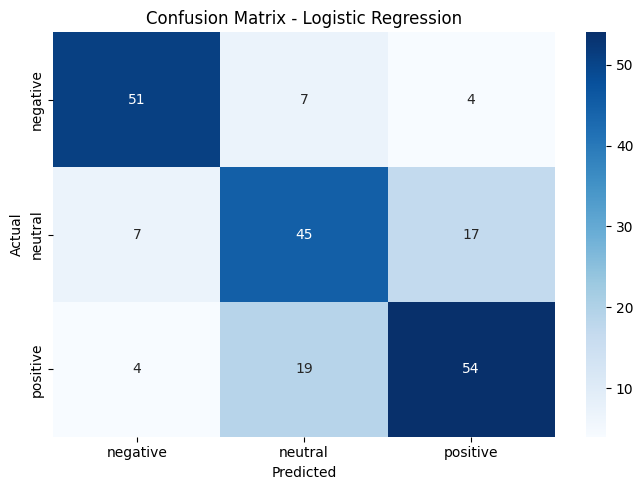

In [27]:
best_model_name = final_results_df.loc[0, 'Model']
print('Best model:', best_model_name)

if best_model_name == 'IndoBERT Fine-tuning':
    best_pred = y_pred_bert
elif best_model_name == 'IndoBERT + RAG-style Augmentation' and 'y_pred_bert_aug' in globals():
    best_pred = y_pred_bert_aug
else:
    best_pred = tier1_predictions[best_model_name]

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()